## Librerie

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

!pip install -q iminuit
from iminuit import Minuit

zsh:1: command not found: pip


## Parametri


In [100]:
nome_file = "dati_amici.csv"   # nome del file csv

#  r = (x - x0) + D/2 + profondità fotodiodo
x0 = 122.0          # lettura di x con il fotodiodo a contatto con la lampadina (mm)
D_lamp = 16.483     # diametro lampadina (mm)
prof_diodo = 1.0    # profondità del fotodiodo nella scatola (mm)
r_min = 0.0         # usa solo i punti con r >= r_min (mm); 0 = usa tutti

# errori di misura 
dx = 0.2            # errore di lettura su x (mm)
dV_dir = 0.01       # sensibilità voltmetro su V_dir (V)
dV_fondo = 0.01     # sensibilità voltmetro su V_fondo (V)
sigma_x = dx / np.sqrt(3)   

# errori sistematici 
# per decidere alla fine se B è compatibile con 0. 
sigma_x0 = 0.144    # mm
sigma_D = 0.05      # mm (errore sul diametro)
sigma_prof = 0.5    # mm 
sigma_sist = np.sqrt(sigma_x0**2 + (sigma_D / 2)**2 + sigma_prof**2)

## Dati

In [101]:
df = pd.read_csv(nome_file, sep=";", decimal=",", encoding="utf-8-sig")
df = df.dropna(subset=["x [mm]", "V_dir [V]", "V_fondo1 [V]"])   # scarta le righe vuote

pos = df["x [mm]"].to_numpy(dtype=float)       # lettura di x 
V_dir = df["V_dir [V]"].to_numpy(dtype=float)  # tensione con lampada accesa 
fondo = df[["V_fondo1 [V]", "V_fondo2 [V]", "V_fondo3 [V]"]]   # celle vuote = NaN

# tensione di fondo: media delle misure fatte e suo errore
V_fondo = fondo.mean(axis=1).to_numpy() # axis=1 per calcolare la media riga per riga
semidisp = ((fondo.max(axis=1) - fondo.min(axis=1)) / 2).to_numpy() #.to_numpy per convertire in array numpy


# con una sola misura (o misure tutte uguali) si usa la sensibilità del voltmetro
sigma_fondo = np.where(semidisp > 0, semidisp / np.sqrt(3), dV_fondo / np.sqrt(3))

# Grandezze usate nei fit
y = V_dir - V_fondo                              # V netta 
ey = np.sqrt((dV_dir / np.sqrt(3))**2 + sigma_fondo**2) # errore su V 
r = (pos - x0) + D_lamp / 2 + prof_diodo         # distanza vera 
ex = np.full_like(r, sigma_x)   # errore su r, np.full_like crea un array della stessa forma di r, con tutti gli elementi uguali a sigma_x

usa = r >= r_min    # taglio su distanze piccole
y, ey, r, ex = y[usa], ey[usa], r[usa], ex[usa] #qui seleziono solo i punti che soddisfano il taglio

print("numero di punti:", len(y))
print(f"r da {r.min():.1f} a {r.max():.1f} mm")

numero di punti: 231
r da 66.2 a 1862.7 mm


## Fit 1

In [102]:
def derivata(f, r, *par):
    # derivata numerica di f rispetto a r
    dr = 1e-6
    return (f(r + dr/2, *par) - f(r - dr/2, *par)) / dr

def compatibile(valore, atteso, errore):
    # stampa se valore e atteso sono compatibili entro 2 sigma
    t = abs(valore - atteso) / errore
    esito = "compatibile" if t < 2 else "NON compatibile"
    print(f"   |valore - atteso| / errore = {t:.2f}  ->  {esito} (non rientra nei 2 sigma)")

def fitfunc1(r, A, B, C):
    return A / (r - B)**2 + C

def chi2_1(A, B, C):
    sigma = np.sqrt(ey**2 + (ex * derivata(fitfunc1, r, A, B, C))**2)
    return np.sum(((y - fitfunc1(r, A, B, C)) / sigma)**2)

# parametri iniziali: A dal primo punto, B e C a zero
m1 = Minuit(chi2_1, A=y[0]*r[0]**2, B=0.0, C=0.0)
m1.errordef = 1 #qui voglio minimizzare il chi2, quindi errordef = 1
m1.migrad() 
m1.hesse() 

A1, B1, C1 = m1.values["A"], m1.values["B"], m1.values["C"] 
eA1, eB1, eC1 = m1.errors["A"], m1.errors["B"], m1.errors["C"]
chi2_min1 = m1.fval
ndof1 = len(r) - 3 

print("fit converge:", m1.valid) 
print(f"A = {A1:5.5g} ± {eA1:5.2g}")
print(f"B = {B1:5.4g} ± {eB1:5.2g}")
print(f"C = {C1:5.4g} ± {eC1:5.2g}")
print(f"chi2/ndof = {chi2_min1:5.4g}/{ndof1}") 

print("\nB compatibile con 0? (errore statistico + sistematico)")
compatibile(B1, 0, np.sqrt(eB1**2 + sigma_sist**2))
print("C compatibile con 0?")
compatibile(C1, 0, eC1)

fit converge: True
A = 24686 ±    53
B = 7.781 ± 0.084
C = 0.01997 ± 0.00068
chi2/ndof =  3909/228

B compatibile con 0? (errore statistico + sistematico)
   |valore - atteso| / errore = 14.74  ->  NON compatibile (non rientra nei 2 sigma)
C compatibile con 0?
   |valore - atteso| / errore = 29.42  ->  NON compatibile (non rientra nei 2 sigma)


## Fit 2

In [103]:
def fitfunc2(r, A, B, C, D):
    return A / np.abs(r - B)**D + C

def chi2_2(A, B, C, D):
    sigma = np.sqrt(ey**2 + (ex * derivata(fitfunc2, r, A, B, C, D))**2)
    return np.sum(((y - fitfunc2(r, A, B, C, D)) / sigma)**2)

m2 = Minuit(chi2_2, A=A1, B=B1, C=C1, D=2.0)
m2.errordef = 1
m2.migrad()
m2.hesse()

A2, B2, C2, D2 = m2.values["A"], m2.values["B"], m2.values["C"], m2.values["D"]
eA2, eB2, eC2, eD2 = m2.errors["A"], m2.errors["B"], m2.errors["C"], m2.errors["D"]
chi2_min2 = m2.fval
ndof2 = len(r) - 4

print("fit converge:", m2.valid)
print(f"A = {A2:5.5g} ± {eA2:5.2g}")
print(f"B = {B2:5.4g} ± {eB2:5.2g}")
print(f"C = {C2:5.4g} ± {eC2:5.2g}")
print(f"D = {D2:5.4g} ± {eD2:5.2g}")
print(f"chi2/ndof = {chi2_min2:5.4g}/{ndof2}")

print("\nD compatibile con 2?")
compatibile(D2, 2, eD2)

fit converge: True
A = 4107.5 ±    25
B = 22.64 ± 0.083
C = -0.0213 ± 0.00073
D = 1.669 ± 0.0011
chi2/ndof =  1730/227

D compatibile con 2?
   |valore - atteso| / errore = 290.77  ->  NON compatibile (non rientra nei 2 sigma)


## Grafico 1: dati, fit e asintoti

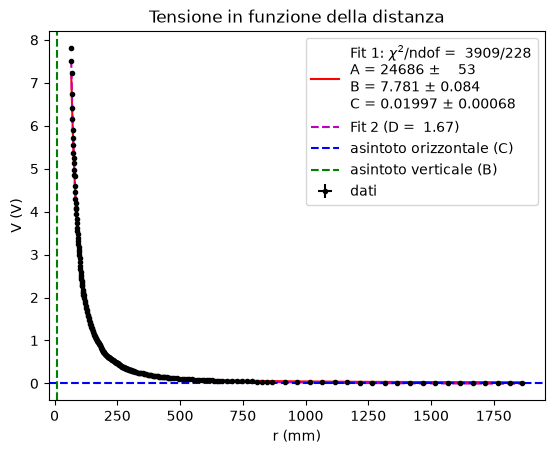

In [104]:
r_fit = np.linspace(r.min(), r.max(), 500)

plt.figure()
plt.errorbar(r, y, xerr=ex, yerr=ey, fmt=".", color="k", label="dati")
plt.plot(r_fit, fitfunc1(r_fit, A1, B1, C1), "r-",
         label=f"Fit 1: $\\chi^2$/ndof = {chi2_min1:5.4g}/{ndof1}\nA = {A1:5.5g} $\\pm$ {eA1:5.2g}\nB = {B1:5.4g} $\\pm$ {eB1:5.2g}\nC = {C1:5.4g} $\\pm$ {eC1:5.2g}")
plt.plot(r_fit, fitfunc2(r_fit, A2, B2, C2, D2), "m--", label=f"Fit 2 (D = {D2:5.3g})")
plt.axhline(C1, linestyle="--", color="b", label="asintoto orizzontale (C)")
plt.axvline(B1, linestyle="--", color="g", label="asintoto verticale (B)")

plt.title("Tensione in funzione della distanza")
plt.xlabel("r (mm)")
plt.ylabel("V (V)")
plt.legend()
plt.savefig("c1.png")
plt.show()

## Grafico 2: residui normalizzati

 5 punti hanno |residuo| > 10 e non compaiono nell'istogramma


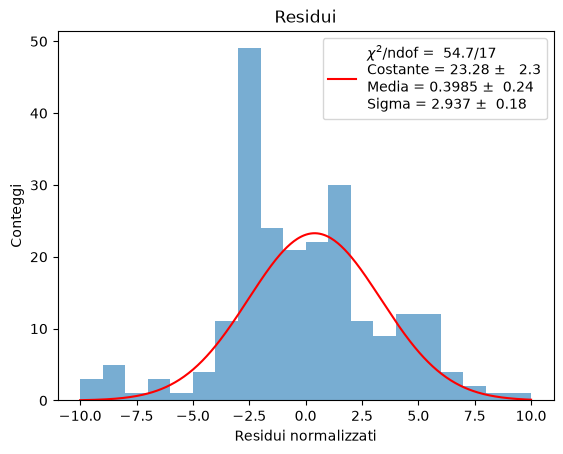

media compatibile con 0?
   |valore - atteso| / errore = 1.69  ->  compatibile (non rientra nei 2 sigma)
sigma compatibile con 1?
   |valore - atteso| / errore = 10.67  ->  NON compatibile (non rientra nei 2 sigma)


In [105]:
ey_eff = np.sqrt(ey**2 + (ex * derivata(fitfunc1, r, A1, B1, C1))**2)
res_norm = (y - fitfunc1(r, A1, B1, C1)) / ey_eff

fuori = np.sum(np.abs(res_norm) > 10)
if fuori > 0:
    print(f" {fuori} punti hanno |residuo| > 10 e non compaiono nell'istogramma")

plt.figure()
counts, bins, _ = plt.hist(res_norm, range=(-10, 10), bins=20, alpha=0.6)
centri = (bins[:-1] + bins[1:]) / 2

def gauss(x, c, media, sigma):
    return c * np.exp(-0.5 * ((x - media) / sigma)**2)

# fit gaussiano solo sui bin non vuoti
mask = counts > 0
popt, pcov = curve_fit(gauss, centri[mask], counts[mask], p0=[counts.max(), 0.0, 1.0],
                       sigma=np.sqrt(counts[mask]), absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))
chi2_h = np.sum(((counts[mask] - gauss(centri[mask], *popt)) / np.sqrt(counts[mask]))**2)
ndof_h = np.count_nonzero(counts) - 3

xg = np.linspace(-10, 10, 400)
plt.plot(xg, gauss(xg, *popt), "r-",
         label=f"$\\chi^2$/ndof = {chi2_h:5.4g}/{ndof_h}\nCostante = {popt[0]:5.4g} $\\pm$ {perr[0]:5.2g}\nMedia = {popt[1]:5.4g} $\\pm$ {perr[1]:5.2g}\nSigma = {abs(popt[2]):5.4g} $\\pm$ {perr[2]:5.2g}")

plt.title("Residui")
plt.xlabel("Residui normalizzati")
plt.ylabel("Conteggi")
plt.legend()
plt.savefig("c2.png")
plt.show()

print("media compatibile con 0?")
compatibile(popt[1], 0, perr[1]) # qui sto confrontando la media dei residui con 0 usando l'errore della media stimato dal fit gaussiano
print("sigma compatibile con 1?")
compatibile(abs(popt[2]), 1, perr[2]) # qui sto confrontando la sigma dei residui con 1 usando l'errore della sigma stimato dal fit gaussiano



## Grafico 3: residui in funzione di r


fit convergito: True
P0 = 0.009793 ± 0.00068
P1 = -2.138e-05 ± 1.1e-06
chi2/ndof =  3549/229

P0 compatibile con 0?
   |valore - atteso| / errore = 14.39  ->  NON compatibile (non rientra nei 2 sigma)
P1 compatibile con 0?
   |valore - atteso| / errore = 18.98  ->  NON compatibile (non rientra nei 2 sigma)


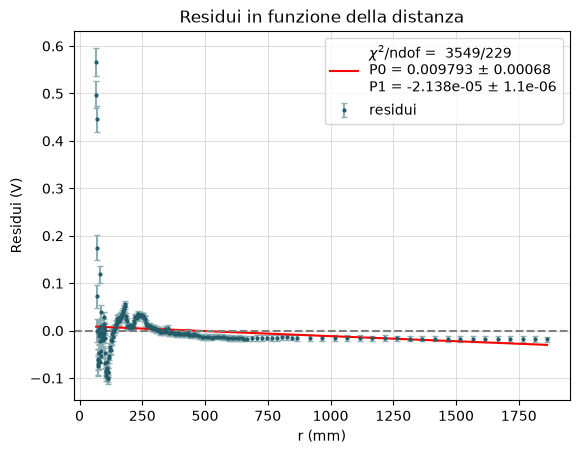

In [106]:
y_res = y - fitfunc1(r, A1, B1, C1)

def retta(r, P0, P1):
    return P0 + P1 * r

def chi2_3(P0, P1):
    return np.sum(((y_res - retta(r, P0, P1)) / ey_eff)**2)

m3 = Minuit(chi2_3, P0=0.0, P1=0.0)
m3.errordef = 1
m3.migrad()
m3.hesse()

P0, P1 = m3.values["P0"], m3.values["P1"]
eP0, eP1 = m3.errors["P0"], m3.errors["P1"]
chi2_min3 = m3.fval
ndof3 = len(r) - 2

print("fit convergito:", m3.valid)
print(f"P0 = {P0:5.4g} ± {eP0:5.2g}")
print(f"P1 = {P1:5.4g} ± {eP1:5.2g}")
print(f"chi2/ndof = {chi2_min3:5.4g}/{ndof3}")

print("\nP0 compatibile con 0?")
compatibile(P0, 0, eP0)
print("P1 compatibile con 0?")
compatibile(P1, 0, eP1)

plt.figure()
plt.errorbar(r, y_res, yerr=ey_eff, fmt=".", markersize=4,
            color='#245b68', ecolor='#8daeb2', capsize=2, label="residui")
plt.plot(r_fit, retta(r_fit, P0, P1), "r-",
         label=f"$\\chi^2$/ndof = {chi2_min3:5.4g}/{ndof3}\nP0 = {P0:5.4g} $\\pm$ {eP0:5.2g}\nP1 = {P1:5.4g} $\\pm$ {eP1:5.2g}")
plt.axhline(0, linestyle="--", color="gray")

plt.title("Residui in funzione della distanza")
plt.grid(alpha=0.4)
plt.xlabel("r (mm)")
plt.ylabel("Residui (V)")
plt.legend()
plt.savefig("c3.png")
plt.show()

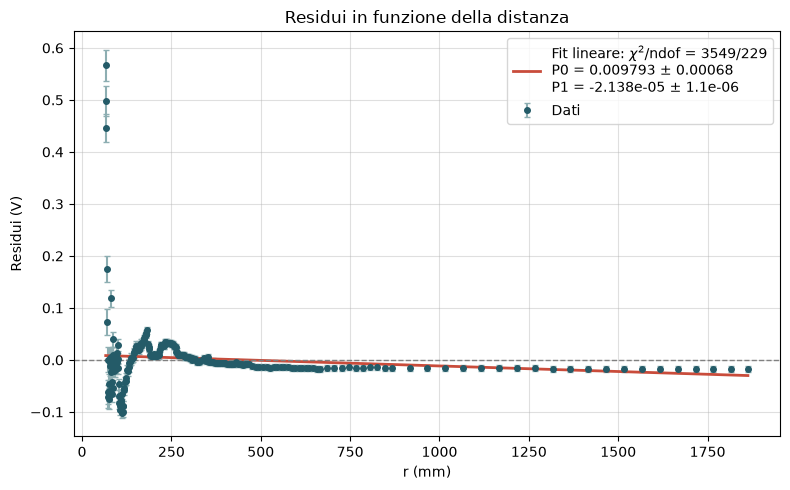

In [107]:
x = r
y_res = y - fitfunc1(r, A1, B1, C1)

def retta(x, par0, par1):
    return par0 + par1 * x

def chi2_residui(par0, par1):
    return np.sum(((y_res - retta(x, par0, par1)) / ey_eff)**2)

m_residui = Minuit(chi2_residui, par0=0.0, par1=0.0)
m_residui.errordef = 1
m_residui.migrad()
m_residui.hesse()

P0_fit, P1_fit = m_residui.values["par0"], m_residui.values["par1"]
P0_err, P1_err = m_residui.errors["par0"], m_residui.errors["par1"]
x_fit = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(x, y_res, yerr=ey_eff, fmt='o', markersize=4,
            color='#245b68', ecolor='#8daeb2', capsize=2, label='Dati')
ax.plot(x_fit, retta(x_fit, P0_fit, P1_fit), color='#c94c3b', linewidth=2,
        label=f"Fit lineare: $\\chi^2$/ndof = {chi2_residui(P0_fit, P1_fit):.4g}/{len(x)-2}\n"
              f"P0 = {P0_fit:.4g} $\\pm$ {P0_err:.2g}\n"
              f"P1 = {P1_fit:.4g} $\\pm$ {P1_err:.2g}")
ax.axhline(0, color='0.5', linewidth=1, linestyle='--')
ax.set_title("Residui in funzione della distanza")
ax.set_xlabel("r (mm)")
ax.set_ylabel("Residui (V)")
ax.grid(alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()